<a href="https://colab.research.google.com/github/TaiwoOlaniyiToheeb/naive_bayes/blob/main/naive_bays.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [164]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [166]:
df = pd.read_csv('/content/drive/MyDrive/colab files/nba.csv')
df.head()

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304


In [167]:
df.shape

(1340, 11)

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fg            1340 non-null   float64
 1   3p            1340 non-null   float64
 2   ft            1340 non-null   float64
 3   reb           1340 non-null   float64
 4   ast           1340 non-null   float64
 5   stl           1340 non-null   float64
 6   blk           1340 non-null   float64
 7   tov           1340 non-null   float64
 8   target_5yrs   1340 non-null   int64  
 9   total_points  1340 non-null   float64
 10  efficiency    1340 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 115.3 KB


In [169]:
df.isnull().sum()

,0
fg,0
3p,0
ft,0
reb,0
ast,0
stl,0
blk,0
tov,0
target_5yrs,0
total_points,0


In [170]:
df.describe()

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
count,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,44.169403,19.149627,70.300299,3.034478,1.550522,0.618507,0.368582,1.193582,0.620149,451.783358,0.371078
std,6.137679,16.051861,10.578479,2.057774,1.471169,0.409759,0.429049,0.722541,0.485531,366.520093,0.093659
min,23.800000,0.000000,0.000000,0.300000,0.000000,0.000000,0.000000,0.100000,0.000000,14.700000,0.121951
25%,40.200000,0.000000,64.700000,1.500000,0.600000,0.300000,0.100000,0.700000,0.000000,172.800000,0.306710
50%,44.100000,22.200000,71.250000,2.500000,1.100000,0.500000,0.200000,1.000000,1.000000,338.350000,0.363325
75%,47.900000,32.500000,77.600000,4.000000,2.000000,0.800000,0.500000,1.500000,1.000000,639.675000,0.431326
max,73.700000,100.000000,100.000000,13.900000,10.600000,2.500000,3.900000,4.400000,1.000000,2312.400000,0.738462


In [171]:
bat_mat = df.corr()
bat_mat

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
fg,1.000000,-0.336502,-0.161183,0.465423,-0.108797,0.056658,0.391626,0.121806,0.227134,0.267040,0.292329
3p,-0.336502,1.000000,0.332458,-0.193082,0.266898,0.198237,-0.246358,0.111495,-0.000004,0.128182,0.089444
ft,-0.161183,0.332458,1.000000,-0.071105,0.296315,0.207205,-0.161152,0.199742,0.106706,0.244441,0.234172
reb,0.465423,-0.193082,-0.071105,1.000000,0.119081,0.381154,0.699672,0.536716,0.299406,0.678547,0.278036
ast,-0.108797,0.266898,0.296315,0.119081,1.000000,0.751289,-0.086470,0.747286,0.175353,0.551626,0.163929
stl,0.056658,0.198237,0.207205,0.381154,0.751289,1.000000,0.133808,0.741988,0.229811,0.663161,0.226355
blk,0.391626,-0.246358,-0.161152,0.699672,-0.086470,0.133808,1.000000,0.282150,0.210114,0.390593,0.142197
tov,0.121806,0.111495,0.199742,0.536716,0.747286,0.741988,0.282150,1.000000,0.272348,0.839687,0.458450
target_5yrs,0.227134,-0.000004,0.106706,0.299406,0.175353,0.229811,0.210114,0.272348,1.000000,0.358493,0.194486
total_points,0.267040,0.128182,0.244441,0.678547,0.551626,0.663161,0.390593,0.839687,0.358493,1.000000,0.592207


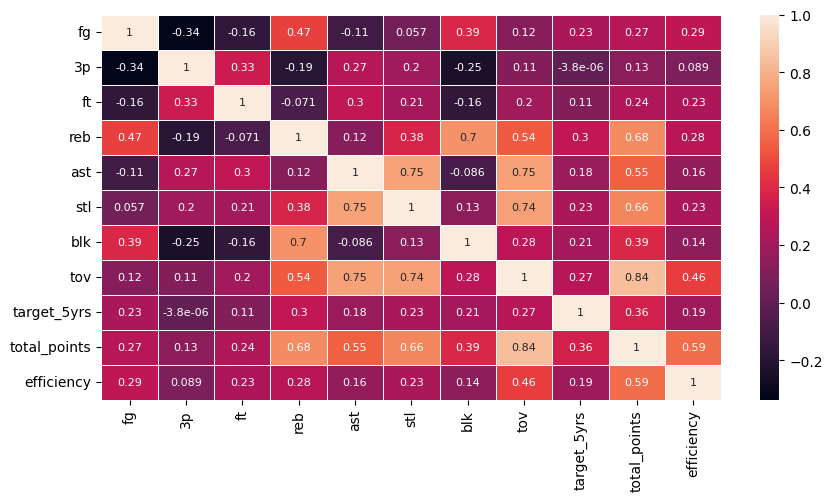

In [172]:
plt.figure(figsize = (10, 5))
sns.heatmap(bat_mat, annot = True, annot_kws = {'size' : 8}, linewidths = .6, linecolor = 'white')
plt.show()

### Target Value

In [173]:
df['target_5yrs'].value_counts()

,count
target_5yrs,
1,831
0,509


In [174]:
df['target_5yrs'].value_counts(normalize = True) * 100

,proportion
target_5yrs,
1,62.014925
0,37.985075


There are 831, 1 values in the target column accounting 62.01% and 509, 0 values accounting for 37.99%. This is a fairly balanced target values. This is not major imbalance and is ready for machine learning.

In [175]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score, precision_score, recall_score

In [176]:
X = df.drop(['target_5yrs'], axis = 1)
y = df['target_5yrs']

In [177]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [178]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1072, 10), (268, 10), (1072,), (268,))

In [179]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

In [180]:
print("Number of mislabeled points out of a total %d points : %d"% (X_test.shape[0], (y_test != y_pred).sum()))

Number of mislabeled points out of a total 268 points : 90


In [181]:
print(f'Accuracy Score : {accuracy_score(y_test, y_pred)}')
print(f'Precision Score : {precision_score(y_test, y_pred)}')
print(f'F1 Score : {f1_score(y_test, y_pred)}')
print(f'Confusion Matrix : \n{confusion_matrix(y_test, y_pred)}')

Accuracy Score : 0.664179104477612
Precision Score : 0.8691588785046729
F1 Score : 0.6739130434782609
Confusion Matrix : 
[[85 14]
 [76 93]]


In [182]:
print(f"Recall Score: {recall_score(y_test, y_pred)}")

Recall Score: 0.5502958579881657


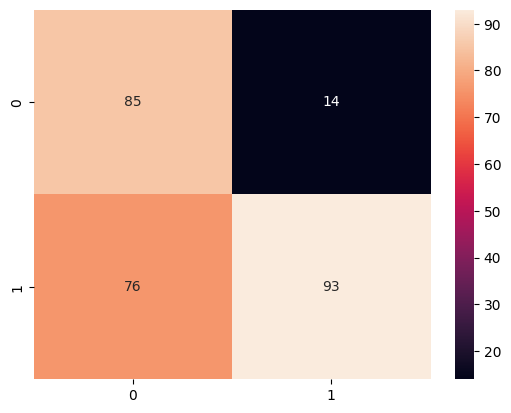

In [183]:
o_fit =  confusion_matrix(y_test, y_pred)
sns.heatmap(o_fit, annot = True, fmt = 'd')
plt.show()

There are 90 mis-classified profiles. We will run tunning

In [184]:
cl_rep_dict = classification_report(y_test, y_pred, output_dict=True)
cl = pd.DataFrame(cl_rep_dict).transpose()
cl

,precision,recall,f1-score,support
0,0.527950,0.858586,0.653846,99.000000
1,0.869159,0.550296,0.673913,169.000000
accuracy,0.664179,0.664179,0.664179,0.664179
macro avg,0.698555,0.704441,0.663880,268.000000
weighted avg,0.743115,0.664179,0.666500,268.000000


In [185]:
from sklearn.model_selection import GridSearchCV

In [186]:
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
}
gsv = GridSearchCV(estimator = GaussianNB(), param_grid = param_grid, verbose = 1, cv = 5, n_jobs = -1)
gsv.fit(X_train, y_train)
print(gsv.best_estimator_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
GaussianNB(var_smoothing=np.float64(0.533669923120631))


In [187]:
y_pred = gsv.predict(X_test)


In [188]:
print(f'Accuracy Score : {accuracy_score(y_test, y_pred)}')

Accuracy Score : 0.6902985074626866


In [189]:
con_ma = confusion_matrix(y_test, y_pred)
con_ma

array([[ 51,  48],
       [ 35, 134]])

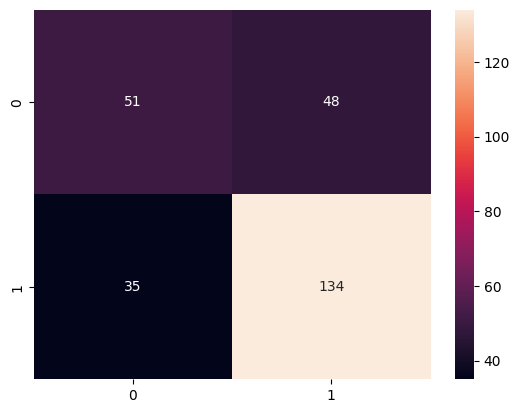

In [190]:
sns.heatmap(con_ma, annot = True, fmt = 'd')
plt.show()

In [191]:
print(f"Recall Score: {recall_score(y_test, y_pred)}")

Recall Score: 0.7928994082840237


In [192]:
print(y_test.value_counts())
print(y_pred)

target_5yrs
1    169
0     99
Name: count, dtype: int64
[0 0 1 0 0 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 1
 1 1 0 1 0 1 1 1 0 0 0 0 1 1 1 0 0 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 1 0 1
 1 0 1 1 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 0
 0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1
 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 0 0 1 1
 0 1 1 1 0 1 1 0 0 1 0 1 1 1 0 0 1 1 0 1 1 0 1 1 0 0 0 1 1 1 1 0 0 1 1 1 1
 1 0 1 1 0 1 1 1 1]


In [193]:
print(pd.Series(y_pred).value_counts())

1    182
0     86
Name: count, dtype: int64


In [194]:
print(f'Precision Score : {precision_score(y_test, y_pred)}')
print(f'F1 Score : {f1_score(y_test, y_pred)}')

Precision Score : 0.7362637362637363
F1 Score : 0.7635327635327636


In [195]:
pd.DataFrame({
    'Feature': X.columns,
    'Class_0_Mean': gsv.best_estimator_.theta_[0],
    'Class_1_Mean': gsv.best_estimator_.theta_[1]
}).head()

,Feature,Class_0_Mean,Class_1_Mean
0,fg,42.412439,45.212991
1,3p,19.408049,19.278852
2,ft,68.877317,71.308308
3,reb,2.274146,3.440483
4,ast,1.241220,1.760121


Hyperparameter tuning improved the Gaussian Naive Bayes model's ability to identify players likely to remain in the league for at least five years. Accuracy increased from 66.4% to 69.0%, recall improved substantially from 55.0% to 79.3%, and F1-score increased from 0.674 to 0.764. However, precision decreased from 86.9% to 73.6%, indicating a higher number of false positives. This reflects the inherent tradeoff between precision and recall. Depending on whether the objective is to avoid drafting busts or avoid missing talented players, either model may be preferred.

## Naive Bayes Independence Assumption

Naive Bayes is called "naive" because it assumes that all predictor variables are **conditionally independent** given the target class. In other words, once we know whether a player will remain in the league for at least five years (`target_5yrs`), the model assumes that one feature does not influence another.

For example, the model assumes:

* Points scored is independent of minutes played.
* Rebounds are independent of games played.
* Assists are independent of field goals made.

Mathematically, the probability of a player belonging to a class is computed as:

[
P(X|Y) = P(x_1|Y)P(x_2|Y)\cdots P(x_n|Y)
]

where the features are treated as independent of one another.

However, this assumption is often unrealistic in basketball data because many player statistics are naturally correlated.

### Examples of correlated basketball statistics

* **Points and minutes played:** Players who play more minutes generally score more points.
* **Field goals made and points:** More made shots directly increase points scored.
* **Rebounds and minutes played:** Players on the court longer usually collect more rebounds.
* **Assists and usage rate:** Players with greater offensive roles tend to record more assists.

Because these relationships exist, the independence assumption is violated in practice.

Despite this limitation, Naive Bayes often performs surprisingly well because it focuses on classification accuracy rather than perfectly modeling the underlying relationships between variables.

---

## Model Reliability for a Scouting Department

The Gaussian Naive Bayes model provides a useful data-driven tool for identifying players likely to remain in the NBA for at least five years. Hyperparameter tuning improved the model's ability to detect future long-term players by substantially increasing recall.

### Strengths

* Fast and computationally efficient.
* Easy to interpret and implement.
* Performs well even with relatively small datasets.
* Successfully identifies a large proportion of future long-term players.
* Can serve as an objective supplement to traditional scouting.

### Limitations

* Assumes independence among player statistics, which is unrealistic in basketball.
* May oversimplify complex relationships between player attributes.
* Sensitive to the assumption that features follow a Gaussian distribution.
* Cannot capture nonlinear interactions between variables.
* Model predictions should not replace expert scouting evaluations.

---

